In [10]:
import pandas as pd

df= pd.read_excel(r"D:\Github\chuangxintou\创新投雪球管理.xlsx",sheet_name="合约状态")
import datetime
today = datetime.date.today().strftime("%Y%m%d")
print(today)
# today = "20260604"
underlying_close = 8420.1

20260630


In [11]:
df

,合约编号,合约类型,名义本金,挂钩标的,起息日期,期初价格,敲入点位,临近敲出观察日,敲出票息率,敲出票息,...,Unnamed: 125,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134
0,30,早利雪球,12000000,000852.SH,2026-06-09 15:00:00,8318.70,5407.1550,2026-09-09,0.20000,6.008219e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29,早利雪球,12000000,000852.SH,2026-06-05 15:00:00,8406.76,5464.3940,2026-09-07,0.20000,6.139726e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26（零售）,早利雪球,1800000,000852.SH,2026-05-28 15:00:00,8637.74,5614.5310,2026-08-28,0.22000,9.913562e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25（零售）,DCN,16020000,000852.SH,2026-05-28 15:00:00,8637.74,5614.5310,2026-08-28,NaN,NaN,...,0.0065,0.0065,0.0065,0.0065,0.0065,0.0065,0.0065,0.0065,0.0065,0.0065
4,24,凤凰,30000000,000852.SH,2026-05-15 15:00:00,8810.00,5726.5000,2026-08-17,NaN,NaN,...,0.0100,0.0100,0.0100,0.0100,0.0100,0.0100,0.0100,0.0100,0.0100,0.0100
5,23,经典雪球,14000000,000852.SH,2026-05-15 15:00:00,8820.05,6174.0350,2026-08-17,0.15000,9.859932e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,22,早利雪球,11000000,000852.SH,2026-05-08 15:00:00,8748.19,5686.3235,2026-08-10,0.21500,6.050188e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,21,早利雪球,11000000,000852.SH,2026-05-06 15:00:00,8574.56,5573.4640,2026-08-06,0.16000,4.406027e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,28（零售）,早利雪球,5000000,000852.SH,2026-04-30 15:00:00,8381.95,5867.3650,2026-07-31,0.28000,3.504795e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,27（零售）,DCN,19750000,000852.SH,2026-04-30 15:00:00,8381.95,5867.3650,2026-07-31,NaN,NaN,...,0.0070,0.0070,0.0070,0.0070,0.0070,0.0070,0.0070,0.0070,0.0070,0.0070


In [12]:
ki_positions = df["敲入点位"].values
ko_positions = df["期初价格"].values
notional_values = df["名义本金"].values



relative_ki_positions = (ki_positions - underlying_close) / underlying_close
relative_ko_positions = (ko_positions - underlying_close) / underlying_close


In [13]:
relative_ki_positions

array([-0.3578277 , -0.3510298 , -0.33319901, -0.33319901, -0.31990119,
       -0.26675039, -0.32467269, -0.33807627, -0.30317158, -0.30317158,
       -0.35628146])

In [14]:
relative_ko_positions

array([-0.01204261, -0.0015843 ,  0.02584767,  0.02584767,  0.04630586,
        0.04749944,  0.0389651 ,  0.0183442 , -0.00453083, -0.00453083,
       -0.00966378])

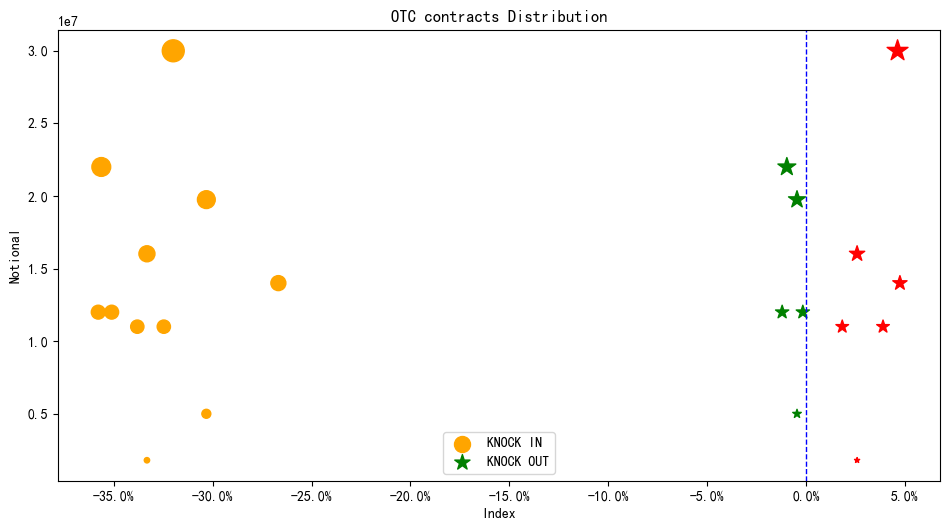

In [15]:
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import os
import numpy as np
folder_path = r"D:\Github\chuangxintou"
underlying_prices = np.linspace(min(ki_positions), max(ko_positions), 100)

fig, ax = plt.subplots(figsize=(16*0.6, 9*0.6))
size_point = 15
ax.scatter(relative_ki_positions,notional_values, label='KNOCK IN', color='orange', marker='o', s = size_point * notional_values/
           np.min(notional_values), linestyle='None')
colors = ['r' if value > 0 else 'g' for value in  relative_ko_positions]

ax.scatter(relative_ko_positions,notional_values, label='KNOCK OUT', marker='*', s=size_point*notional_values/np.min(notional_values), linestyle='None', color= colors)
# ax.bar(relative_ki_positions,notional_values, label='KNOCK IN',width=0.005, color='orange')
# ax.bar(relative_ko_positions, notional_values, label='KNOCK OUT', width=0.005, color=colors)
ax.axvline(
    x=0,                 # index of "C"
    linestyle="--",      # dashed line
    linewidth=1,
    color="blue",         # red color
)
plt.xlabel('Index') 
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.00))
plt.ylabel('Notional') 
plt.title('OTC contracts Distribution') 
plt.legend(frameon=True, loc='best') 
plt.tight_layout()
plt.savefig(os.path.join(folder_path, 'IMAGES\\otc_contracts_distribution_%s.png'%today), dpi=100)
plt.show()  


当前工作目录: d:\Github\chuangxintou

添加估值总和列名后的历史行情数据:
Index(['date', '000016.SH', '000300.SH', '000905.SH', '000852.SH',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', '估值总和'],
      dtype='object')
找到日期: 2025-12-31 00:00:00
d:\Github\chuangxintou d:\Github\chuangxintou\IMAGES\dividend_plot.png
Current date and time:  2026-06-30 15:57:43.506714


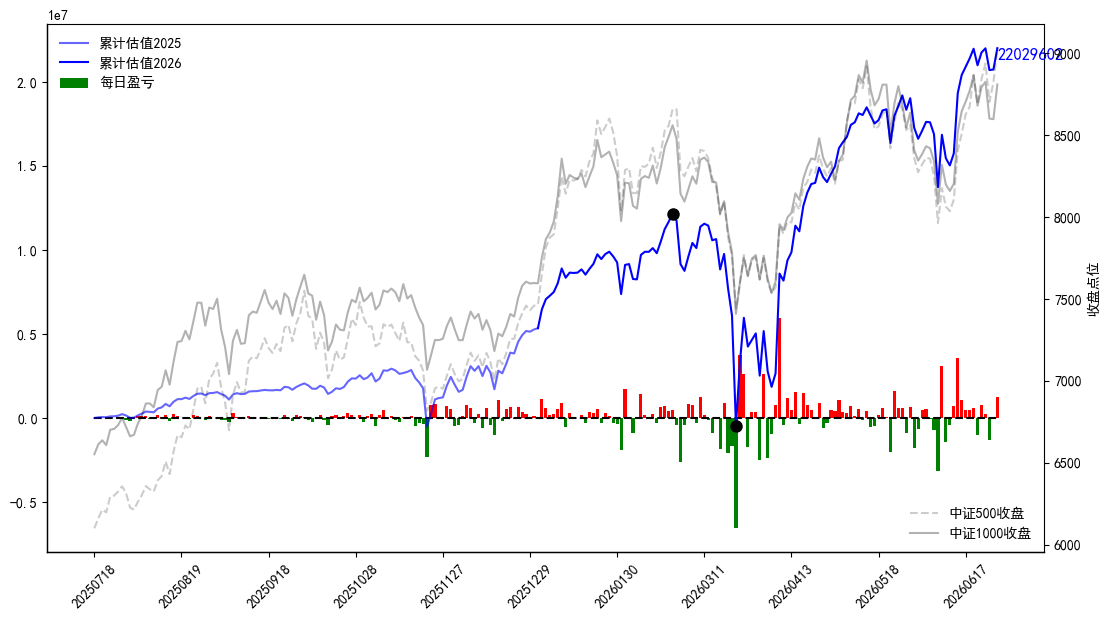

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import os
import warnings
from matplotlib.gridspec import GridSpec
import datetime
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置当前目录
current_dir = os.getcwd()
folder_path = current_dir

print(f"当前工作目录: {current_dir}")

# 读取Excel文件
excel_file = os.path.join(current_dir, '创新投雪球管理.xlsx')

# 读取历史行情sheet
# 第1行是列名，从第4行开始读取数据（header=1，因为pandas从0开始计数）
df_history = pd.read_excel(excel_file, sheet_name='历史行情', header=1)
# print("原始历史行情数据:")
# print(df_history.head())
# print(f"\n原始历史行情数据形状: {df_history.shape}")

# 删除前两行（第2行和第3行是没用的）
df_history = df_history.iloc[2:].reset_index(drop=True)
# print("\n删除前两行后的历史行情数据:")
# print(df_history.head())
# print(f"\n删除前两行后的历史行情数据形状: {df_history.shape}")

# 给第0列添加"date"列名
df_history.columns = ['date'] + list(df_history.columns[1:])
# print("\n添加date列名后的历史行情数据:")
# print(df_history.head())

# 给第9列添加"估值总和"列名
if len(df_history.columns) > 11:
    df_history.columns = list(df_history.columns[:11]) + ['估值总和'] + list(df_history.columns[12:])
    print("\n添加估值总和列名后的历史行情数据:")
    # print(df_history.head())

# 删除最后两行
df_history = df_history.iloc[:-2]
# print("\n删除最后两行后的历史行情数据:")
# print(df_history.head())
# print(f"\n删除最后两行后的历史行情数据形状: {df_history.shape}")

# 确保日期列是datetime类型
df_history['date'] = pd.to_datetime(df_history['date'])

# 计算每天的涨跌
# df_history['涨跌'] = df_history['估值总和'].diff()

def maximum_drawdown(prices):
    """
    计算最大回撤及其区间。

    :param prices: 股票价格序列（列表或NumPy数组）
    :return: 最大回撤值和最大回撤区间（开始索引和结束索引）
    """
    # 转换为 NumPy 数组
    prices = np.array(prices)
    
    # 示例使用
    cumulative_sum = prices.cumsum()  # 计算积分

    data =np.array( cumulative_sum)
    # max_dd, (start, end) = maximum_drawdown(prices)

    index_j = np.argmax(np.maximum.accumulate(data) - data)  # 结束位置
    # print(index_j)                      ###maximum loss
    index_i = np.argmax(data[:index_j])  # 开始位置
    # print(index_i)                       ##maximum gain
    d = data[index_j] - data[index_i]  # 最大回撤
    return(d, index_i, index_j)

def plot_dividend(df):


    # df.rename(columns={ "估值":"估值总和", '日期':"date"}, inplace=True)
    print(df.columns)
    df['PV'] = df['估值总和']
    df['PV_DIFF'] = df['估值总和'].diff()
    df.loc[0, 'PV_DIFF'] = 0
    # print(df.head())


    times_str = []
    tt = df['date']
    for t in tt:
        times_str.append(t.strftime('%Y%m%d'))
    # 查找特定日期
    target_date = '20251231'  # 要寻找的日期
    if target_date in times_str:
        index = times_str.index(target_date)
        found_date = df['date'].iloc[index]
        print(f"找到日期: {found_date}")
    else:
        print("未找到日期 2025-12-31")

    fig = plt.figure(figsize=( 16*0.7, 9*0.7))
    gs = GridSpec(nrows=1, ncols=1)#, width_ratios=[3, 1, 1, 0], height_ratios=[1, 1])

    # 第一个子图：绘制 qdt 列的散点图

    ax1 = fig.add_subplot(gs[0, 0])  # 第一行，占据前 3 列ax3 = fig.add_subplot(2,1)
    colors = ['red' if value > 0 else 'green' for value in  df['PV_DIFF']]
    line1 = ax1.bar(times_str, df['PV_DIFF'], label = '每日盈亏', color = colors)
    ax1.plot(times_str, df['PV'] * 0, 'k--')
    ax1.text(times_str[-1], df['PV'].iloc[-1],f'{round(df["PV"].iloc[-1]):d}', fontsize=12, color='blue', verticalalignment='top')
    data =np.array( df['PV'])
    # print('近一个月累积收益：' , data[-1])

    # ax1.plot(times_str,  df['PV'], 'b', label='累计估值')
    line2 = ax1.plot(times_str[:index+1],  df['PV'][:index+1], 'b',alpha = 0.6, label='累计估值2025')
    line3 = ax1.plot(times_str[index:],  df['PV'][index:], 'b',alpha = 1, label='累计估值2026')

    down, index_i, index_j = maximum_drawdown(df['PV_DIFF'])
    ax1.plot([index_i, index_j], [data[index_i], data[index_j]], 'o', color="k", markersize=8)
    itv = int(len(df)/10)
    if len(df)>63:
        pass
    else:
        itv =1
    # 设置每 60 个数据点一个 xtick
    ax1.set_xticks(times_str[::itv])
    ax1.set_xticklabels(times_str[::itv], rotation=45)
    # ax1.grid(True)
    # yticks = ax1.get_yticks()
    # ax1.set_yticklabels([f'{val/1e7:.2f}千万' for val in yticks])
    ax1.legend(loc='upper left',frameon=False)
    # lines = [line1, line2, line3]  # 将两条线的 Handles 组合在一起
    # labels = [line1.get_label(), line2.get_label(), line3.get_label()]  # 获取每条线的标签
    close   = 1
    if close:
        # 创建共享 X 轴的右侧 Y 轴
        ax2 = ax1.twinx()  # 创建一个共享 X 轴的新轴
        line4 = ax2.plot(times_str, df['000905.SH'], 'k--',alpha = 0.2, label='中证500收盘')
        line5 = ax2.plot(times_str, df['000852.SH'], color='k',alpha = 0.3, label='中证1000收盘')
        ax2.set_ylabel('收盘点位')
        ax2.legend(loc='lower right',frameon=False)
        # lines = [line1, line2, line3, line4, line5]  # 将两条线的 Handles 组合在一起
        # labels = [line1.get_label(), line2.get_label(), line3.get_label(),line4.get_label(), line5.get_label()]  # 获取每条线的标签
    # 设置背景色和边框
    plt.gca().patch.set_facecolor('#ffffff')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.gca().spines['left'].set_linewidth(1)

    plt.tight_layout()
    print(folder_path, os.path.join(folder_path, 'IMAGES\\dividend_plot.png'))
    plt.savefig(os.path.join(folder_path, 'IMAGES\\dividend_plot.png'), dpi=300)
plot_dividend(df_history)
print("Current date and time: ", datetime.datetime.now())